In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv(r'C:\Users\Bhadmus\Documents\Codeveda Project\cleaned_online_retail.csv')

In [10]:
df.head()

,Invoice,Stockcode,Description,Quantity,Invoicedate,Price,Customer_Id,Country,Revenue,YearMonth
0,536365,85123A,white_hanging_heart_t-light_holder,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12
1,536365,71053,white_metal_lantern,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
2,536365,84406B,cream_cupid_hearts_coat_hanger,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12
3,536365,84029G,knitted_union_flag_hot_water_bottle,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
4,536365,84029E,red_woolly_hottie_white_heart.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12


In [11]:
#STANDARDIZE COLUMN NAMES
# 1. Strip and Replace spaces first
df.columns = df.columns.str.strip().str.replace(' ', '_', regex=False)

# 2. Use .str.title() to capitalize every word
df.columns = df.columns.str.title()

# 3. Check the results
df

,Invoice,Stockcode,Description,Quantity,Invoicedate,Price,Customer_Id,Country,Revenue,Yearmonth
0,536365,85123A,white_hanging_heart_t-light_holder,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30,2010-12
1,536365,71053,white_metal_lantern,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
2,536365,84406B,cream_cupid_hearts_coat_hanger,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00,2010-12
3,536365,84029G,knitted_union_flag_hot_water_bottle,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
4,536365,84029E,red_woolly_hottie_white_heart.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34,2010-12
...,...,...,...,...,...,...,...,...,...,...
401600,581587,22899,children's_apron_dolly_girl,6,2011-12-09 12:50:00,2.10,12680,France,12.60,2011-12
401601,581587,23254,childrens_cutlery_dolly_girl,4,2011-12-09 12:50:00,4.15,12680,France,16.60,2011-12
401602,581587,23255,childrens_cutlery_circus_parade,4,2011-12-09 12:50:00,4.15,12680,France,16.60,2011-12
401603,581587,22138,baking_set_9_piece_retrospot,3,2011-12-09 12:50:00,4.95,12680,France,14.85,2011-12


In [12]:
# TOP 5 CUSTOMERS BY REVENUE
# 1. Groupby and immediately reset_index to keep it as a DataFrame
top_customers = df.groupby('Customer_Id')['Revenue'].sum().sort_values(ascending=False).head(5).reset_index()

# 2. Now 'Revenue' is a column again, so you can change the type
top_customers['Revenue'] = top_customers['Revenue'].astype(int)

# 3. Display
print(top_customers)

   Customer_Id  Revenue
0        14646   279489
1        18102   256438
2        17450   187322
3        14911   132458
4        12415   123725


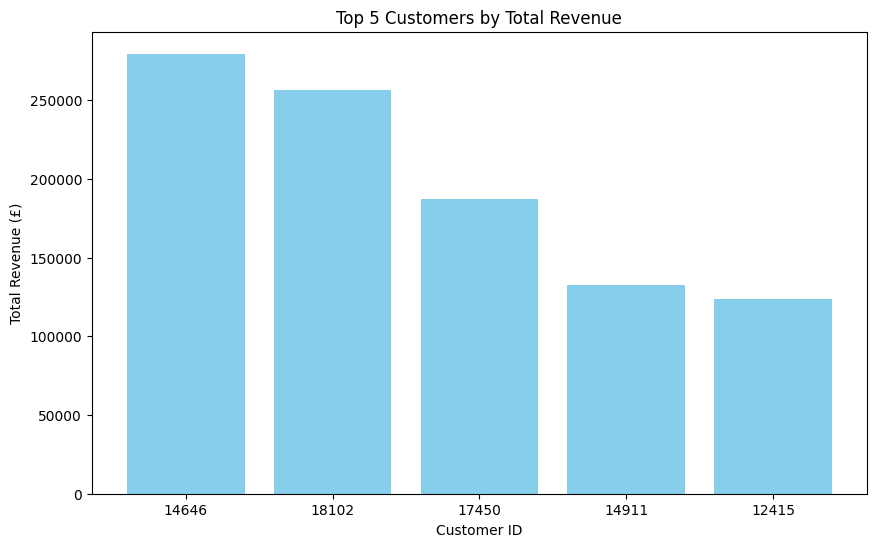

In [13]:
# 1. Convert Customer_Id to string so they aren't plotted on a number line
top_customers['Customer_Id'] = top_customers['Customer_Id'].astype(str)

# 2. Create the plot
plt.figure(figsize=(10,6))
plt.bar(top_customers['Customer_Id'], top_customers['Revenue'], color='skyblue')

# 3. Add labels
plt.xlabel('Customer ID')
plt.ylabel('Total Revenue (£)')
plt.title('Top 5 Customers by Total Revenue')

plt.show()

In [15]:
# 1. Get the sum of revenue for JUST the top 5
top_5_revenue = top_customers['Revenue'].sum()

# 2. Get the total revenue from the entire dataset
total_revenue = df['Revenue'].sum()

# 3. Calculate the share (No need for astype(int) here!)
top_5_share = (top_5_revenue / total_revenue) * 100

print(f"The Top 5 Customers account for {top_5_share:.2f}% of total revenue.")

The Top 5 Customers account for 11.83% of total revenue.


In [16]:
#Country revenue
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).reset_index()
country_revenue['Revenue'] = country_revenue['Revenue'].astype(int)
non_uk_revenue = country_revenue.drop(country_revenue[country_revenue['Country'] == 'United Kingdom'].index)
non_uk_revenue.head(5)

,Country,Revenue
1,Netherlands,284661
2,EIRE,250001
3,Germany,221509
4,France,196644
5,Australia,137009


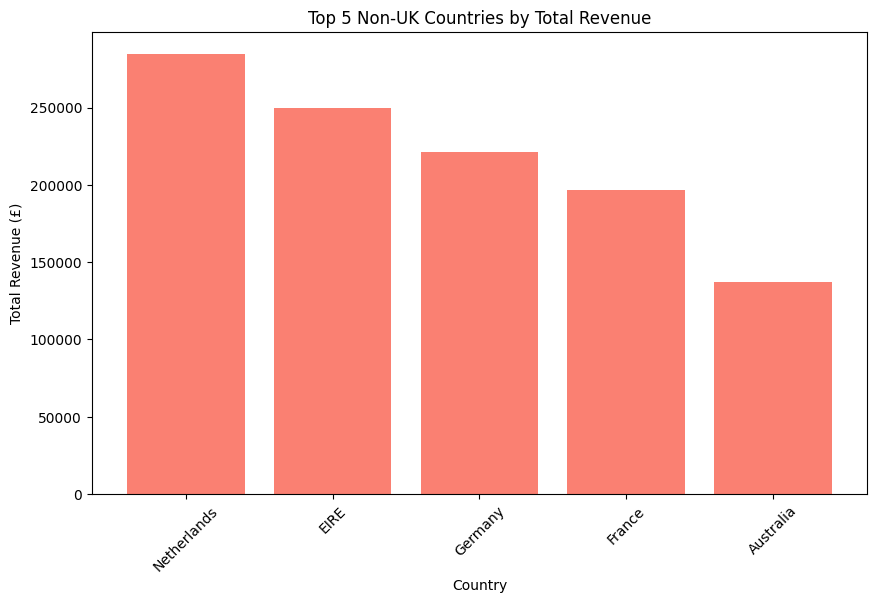

In [17]:
#plot the top 5 non-UK countries by revenue
plt.figure(figsize=(10,6)) 
plt.bar(non_uk_revenue['Country'].head(5), non_uk_revenue['Revenue'].head(5), color='salmon')
plt.xlabel('Country')
plt.ylabel('Total Revenue (£)')
plt.title('Top 5 Non-UK Countries by Total Revenue')
plt.xticks(rotation=45)
plt.show()

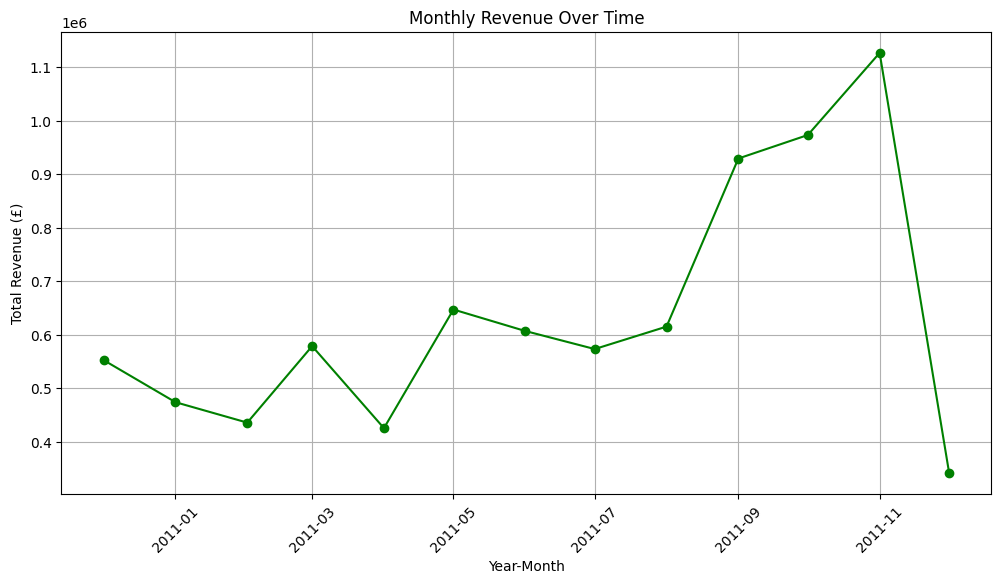

In [18]:
#time series analysis
df['Invoicedate'] = pd.to_datetime(df['Invoicedate'])
df['YearMonth'] = df['Invoicedate'].dt.to_period('M')
monthly_revenue = df.groupby('YearMonth')['Revenue'].sum().reset_index()
monthly_revenue['YearMonth'] = monthly_revenue['YearMonth'].dt.to_timestamp()
plt.figure(figsize=(12,6))
plt.plot(monthly_revenue['YearMonth'], monthly_revenue['Revenue'], marker='o', color='green')
plt.xlabel('Year-Month')
plt.ylabel('Total Revenue (£)')
plt.title('Monthly Revenue Over Time')
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [ ]:
df[df['Quantity'] < 0]
df.drop(df[df['Quantity'] < 0].index, inplace=True)

,Invoice,Stockcode,Description,Quantity,Invoicedate,Price,Customer_Id,Country,Revenue,Yearmonth,YearMonth


In [46]:
df.describe()

,Quantity,Invoicedate,Price,Customer_Id,Revenue
count,392733.000000,392733,392733.000000,392733.000000,392733.000000
mean,13.153687,2011-07-10 19:15:57.956932,3.125633,15287.728182,22.629183
min,1.000000,2010-12-01 08:26:00,0.000000,12346.000000,0.000000
25%,2.000000,2011-04-07 11:12:00,1.250000,13955.000000,4.950000
50%,6.000000,2011-07-31 12:02:00,1.950000,15150.000000,12.390000
75%,12.000000,2011-10-20 12:53:00,3.750000,16791.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,181.588189,NaN,22.240710,1713.570644,311.083069


In [47]:
df[['Revenue', 'Quantity','Price']].agg(['mean', 'median', 'std'])

,Revenue,Quantity,Price
mean,22.629183,13.153687,3.125633
median,12.390000,6.000000,1.950000
std,311.083069,181.588189,22.240710


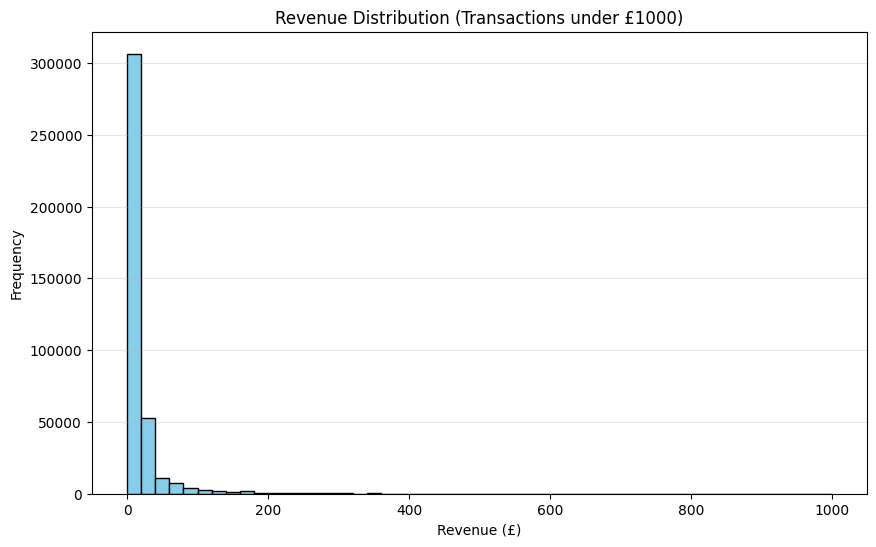

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
# We filter for positive revenue and zoom in on values under £1000
plt.hist(df[df['Revenue'] > 0]['Revenue'], bins=50, range=(0, 1000), color='skyblue', edgecolor='black')

plt.title("Revenue Distribution (Transactions under £1000)")
plt.xlabel("Revenue (£)")
plt.ylabel("Frequency")
plt.grid(axis='y', alpha=0.3)
plt.show()

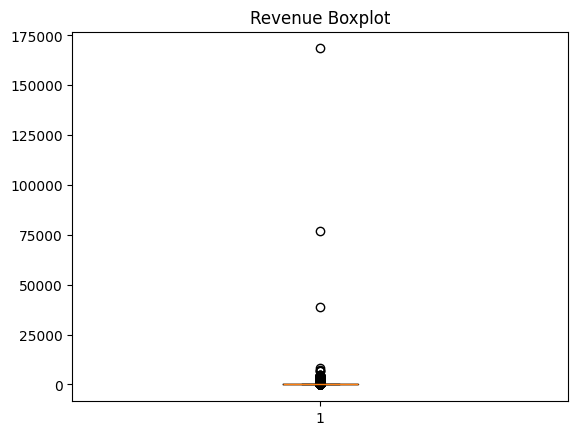

In [49]:
plt.boxplot(df['Revenue'])
plt.title("Revenue Boxplot")
plt.show()

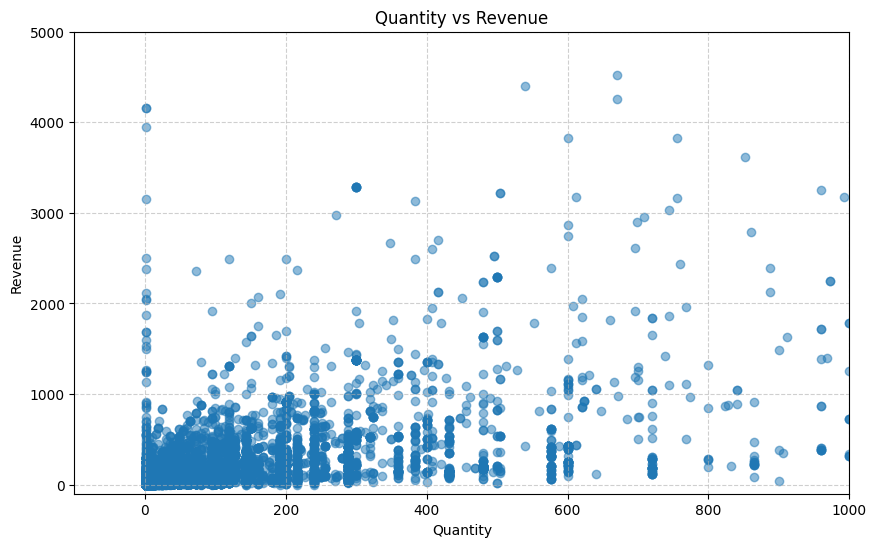

In [54]:
plt.figure(figsize=(10,6))
plt.scatter(df['Quantity'], df['Revenue'], alpha=0.5)

# Zooming in to see the 'normal' transactions
plt.xlim(-100, 1000) 
plt.ylim(-100, 5000)

plt.title('Quantity vs Revenue')
plt.xlabel('Quantity')
plt.ylabel('Revenue')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [57]:
correlation = df[['Quantity', 'Price', 'Revenue']].corr()
correlation 

,Quantity,Price,Revenue
Quantity,1.000000,-0.004577,0.908873
Price,-0.004577,1.000000,0.081620
Revenue,0.908873,0.081620,1.000000
